##### <span style="font-size:32px">Exploratory Data Analysis (EDA)</span>
**Objective:** Understand the dataset, identify patterns, detect anomalies, and generate feature insights.


In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
os.environ["PYTHONWARNINGS"] = "ignore"

##### 1 - Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set(style="whitegrid", palette="muted", font_scale=1.2)

#### 2 - Load Dataset

In [5]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head(30)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
5,5,38,1,4,138,283,0,0,147,1,1.6,2,2,7,Presence
6,6,59,1,4,130,246,0,2,152,0,0.8,2,2,3,Presence
7,7,60,0,3,120,245,0,0,151,0,1.2,1,0,3,Absence
8,8,48,0,4,140,212,0,2,125,0,0.0,1,0,3,Absence
9,9,44,0,4,150,197,0,0,150,0,0.0,2,0,3,Absence


In [6]:
from IPython.display import Markdown

Markdown(f"**Dataset has {train.shape[0]} rows and {train.shape[1]} columns.**")


**Dataset has 630000 rows and 15 columns.**

#### 3 - Missing Values Analysis

In [7]:
missing = train.isnull().sum().sort_values(ascending=False)
missing_percent = (train.isnull().sum()/train.shape[0]*100).sort_values(ascending=False)
missing_df = pd.concat([missing , missing_percent], axis=1 , keys=['Missing values','%'])
missing_df

,Missing values,%
id,0,0.0
Age,0,0.0
Sex,0,0.0
Chest pain type,0,0.0
BP,0,0.0
Cholesterol,0,0.0
FBS over 120,0,0.0
EKG results,0,0.0
Max HR,0,0.0
Exercise angina,0,0.0


 There is no missing value on our dataset

#### 4 -  Target Variable Analysis 

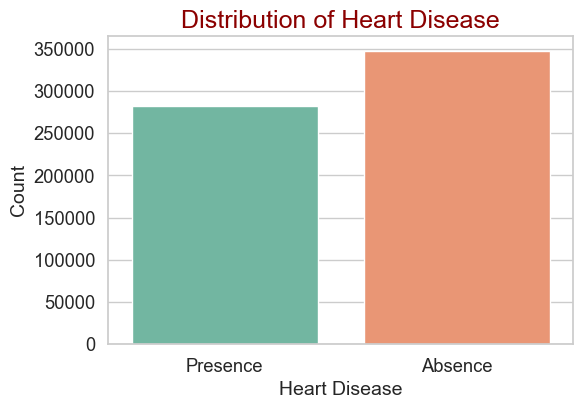

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="Heart Disease", data=train, hue="Heart Disease", palette="Set2", dodge=False, legend=False)
plt.title("Distribution of Heart Disease", fontsize=18, color='darkred')
plt.xlabel("Heart Disease", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.show()

## Model Training & Evaluation
 -----------------------------
#### Objective: Train multiple models on real data and evaluate performance using ROC-AUC
##### We will use advanced models, hyperparameter tuning, and produce high-quality visualizations.

####  Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, log_loss


sns.set(style="whitegrid", palette="Set2", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10,6)

#####  Prepering models

In [10]:
X = train.drop(columns=['Heart Disease'])
y = train['Heart Disease']

le = LabelEncoder()
y_encoded = le.fit_transform(train['Heart Disease'])  # Absence -> 0, Presence -> 1

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    train.drop(columns=['Heart Disease']), 
    y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_train_cols = X_train.columns

X_test_scaled = scaler.transform(test[X_train.columns])
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
}

##### Training and evaluation

In [11]:
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)               
    y_pred = model.predict_proba(X_val_scaled)[:,1] 

    results[name] = {
        "ROC-AUC": roc_auc_score(y_val, y_pred),
        "Log Loss": log_loss(y_val, y_pred)
    }

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)
results_df

[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 679
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383


,ROC-AUC,Log Loss
XGBoost,0.955898,0.266451
LightGBM,0.955858,0.266754
Gradient Boosting,0.955291,0.268600
Logistic Regression,0.951547,0.278691
Random Forest,0.950016,0.307506


####  Model Visualization & Insights
_Visualize baseline model performance to understand where the models succeed or fail._

1 - Feature Importance Visualization

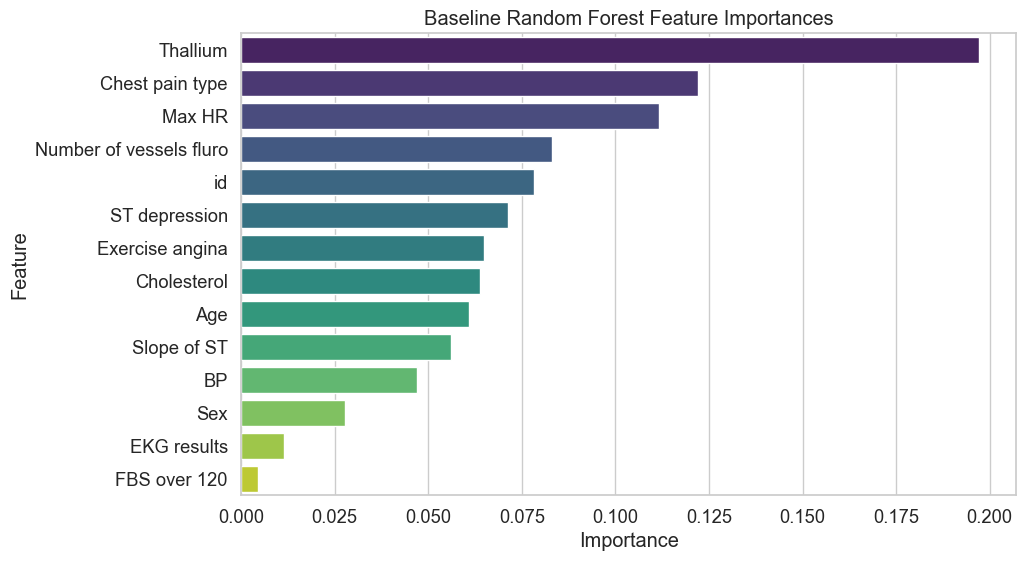

In [12]:
rf_baseline = RandomForestClassifier(n_estimators=200, random_state=42)
rf_baseline.fit(X_train_scaled, y_train)


importances = rf_baseline.feature_importances_
feature_names = X_train.columns
feat_imp_df = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values(by="Importance", ascending=False)


plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_df, palette="viridis")
plt.title("Baseline Random Forest Feature Importances")
plt.show()

2 - ROC Curves for All Models

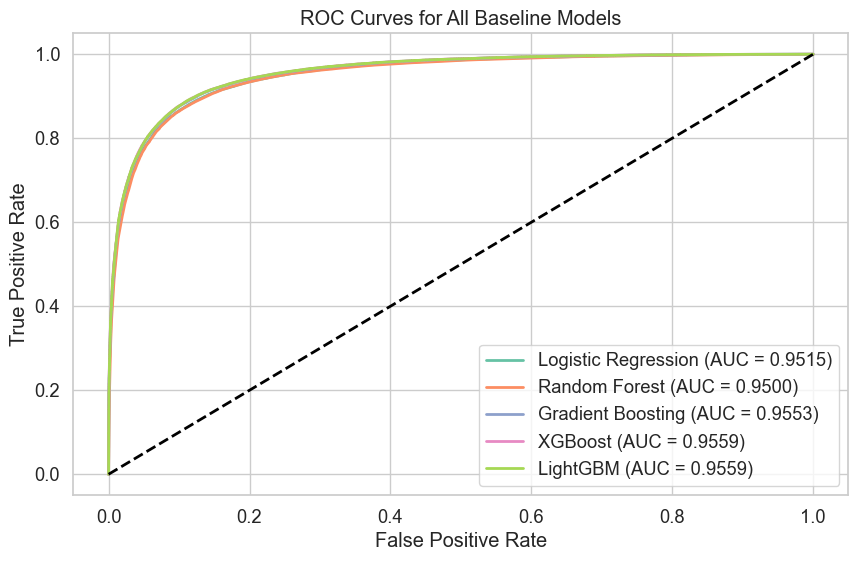

In [13]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_val_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0,1],[0,1], color="black", lw=2, linestyle="--")  # diagonal
plt.title("ROC Curves for All Baseline Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

3 - Confusion Matrices

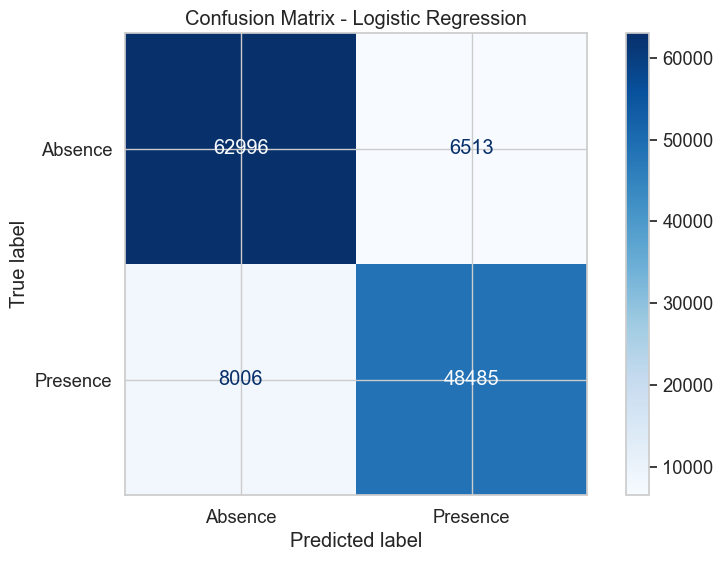

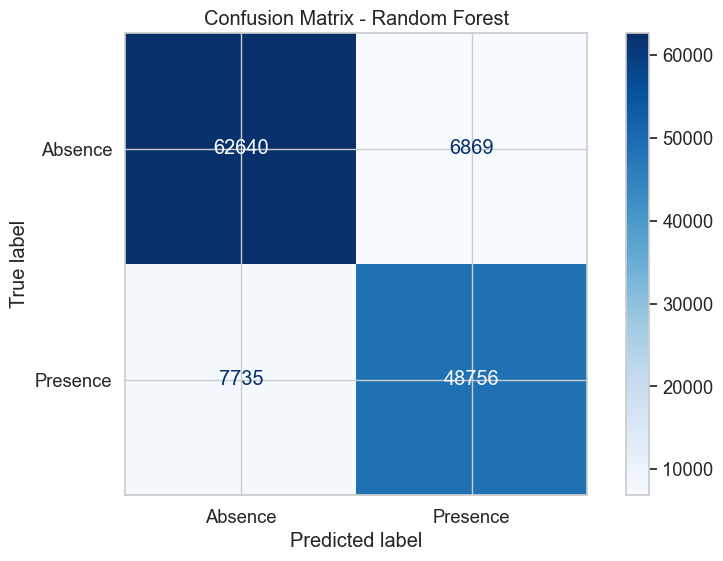

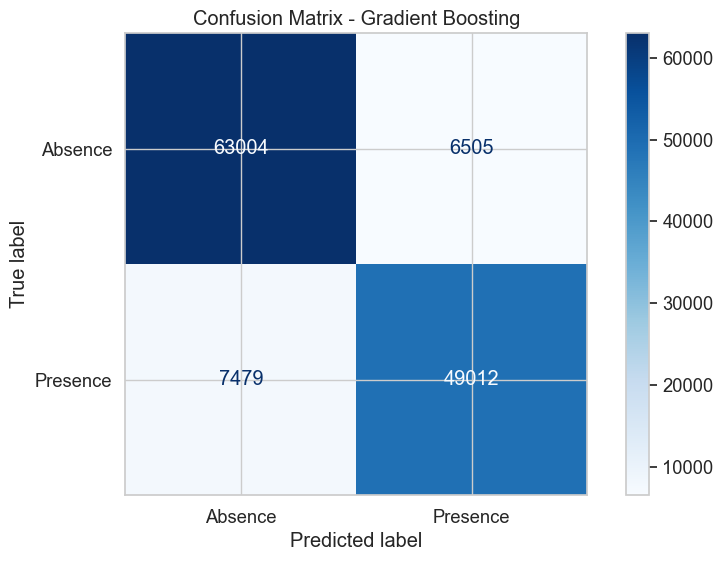

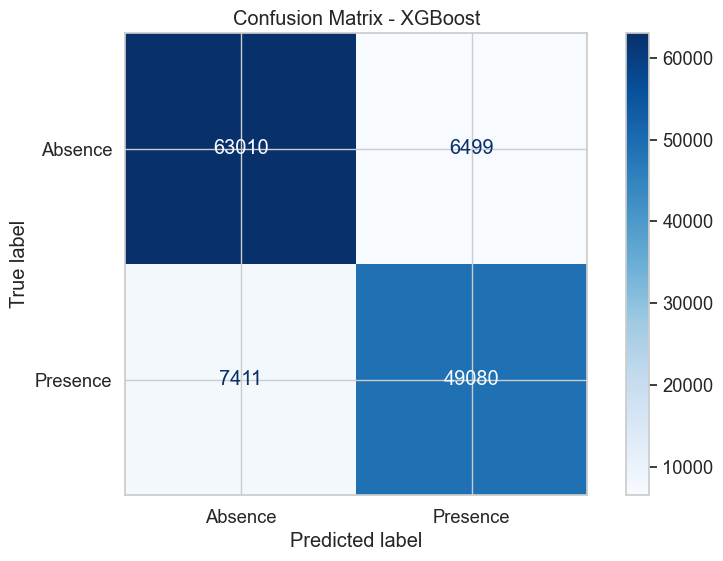

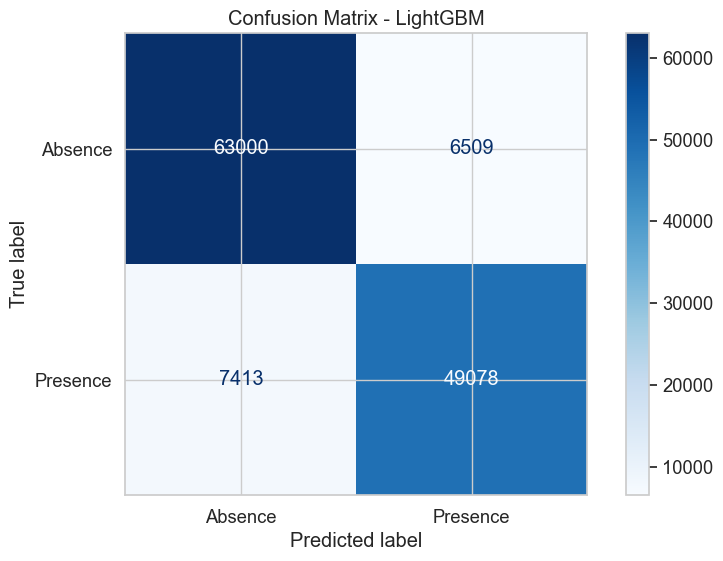

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, model in models.items():
    y_pred_label = model.predict(X_val_scaled)
    cm = confusion_matrix(y_val, y_pred_label)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Absence","Presence"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

## Model Optimization
_After baseline evaluation and visualization, we improve models using hyperparameter tuning, ensembles, and stacking to maximize performance._

1 - Hyperparameter Tuning

In [15]:
from sklearn.model_selection import GridSearchCV


rf_params = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_scaled, y_train)
print("Best RF Params:", rf_grid.best_params_)
print("Best RF ROC-AUC:", rf_grid.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best RF Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}
Best RF ROC-AUC: 0.9520405536523325


3 - Model Stacking / Ensemble

In [16]:
from sklearn.ensemble import StackingClassifier

stack_models = [
    ('rf', RandomForestClassifier(**rf_grid.best_params_, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=200, learning_rate=0.1, eval_metric='logloss', random_state=42)),
    ('lgb', LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42))
]

stack_clf = StackingClassifier(
    estimators=stack_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stack_clf.fit(X_train_scaled, y_train)


,estimators,"[('rf', ...), ('gb', ...), ...]"
,final_estimator,LogisticRegre...max_iter=1000)
,cv,5
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,500
,criterion,'gini'
,max_depth,10
,min_samples_split,5


3 - Stacked Model Evaluation

In [17]:
y_stack_prob = stack_clf.predict_proba(X_val_scaled)[:,1]

from sklearn.metrics import roc_auc_score, log_loss

stack_auc = roc_auc_score(y_val, y_stack_prob)
stack_logloss = log_loss(y_val, y_stack_prob)

print(f"Stacked Model ROC-AUC: {stack_auc:.4f}")
print(f"Stacked Model Log Loss: {stack_logloss:.4f}")

Stacked Model ROC-AUC: 0.9551
Stacked Model Log Loss: 0.2786


4 - Feature Importance from Stacking

In [18]:
for name, model in stack_models:
    if hasattr(model, 'feature_importances_'):
        feat_imp = pd.DataFrame({
            "Feature": X_train.columns,
            "Importance": model.feature_importances_
        }).sort_values("Importance", ascending=False)
        plt.figure(figsize=(10,6))
        sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="coolwarm")
        plt.title(f"{name} Feature Importance (Stacked Base)")
        plt.show()

### Advanced Model Evaluation & Visualizations

1 - ROC Curves for Base & Ensemble Models

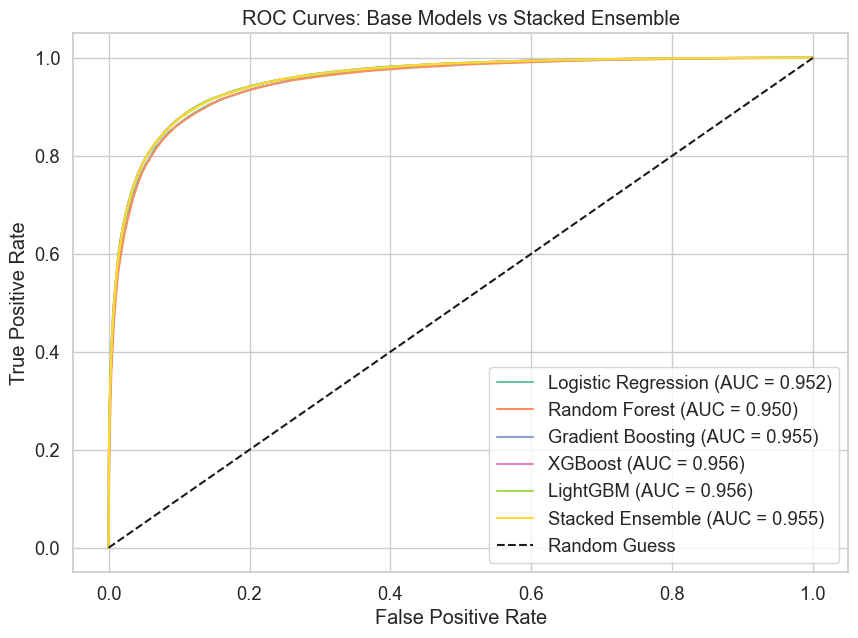

In [19]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,7))

for name, model in {**models, 'Stacked Ensemble': stack_clf}.items():
    if name == 'Stacked Ensemble':
        y_pred_prob = stack_clf.predict_proba(X_val_scaled)[:,1]
    else:
        y_pred_prob = model.predict_proba(X_val_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.title("ROC Curves: Base Models vs Stacked Ensemble")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

2 - Confusion Matrix for Ensemble

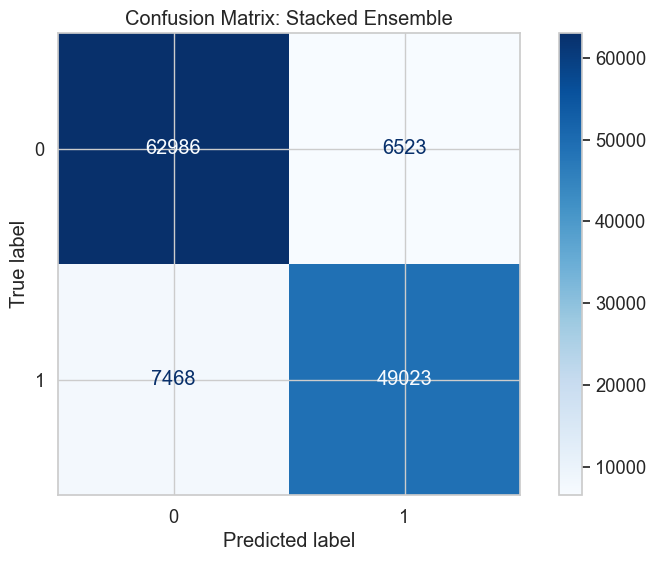

In [20]:

y_val_pred = (stack_clf.predict_proba(X_val_scaled)[:,1] > 0.5).astype(int)
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Stacked Ensemble")
plt.show()

3 - Feature Importance

[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018559 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 679
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383


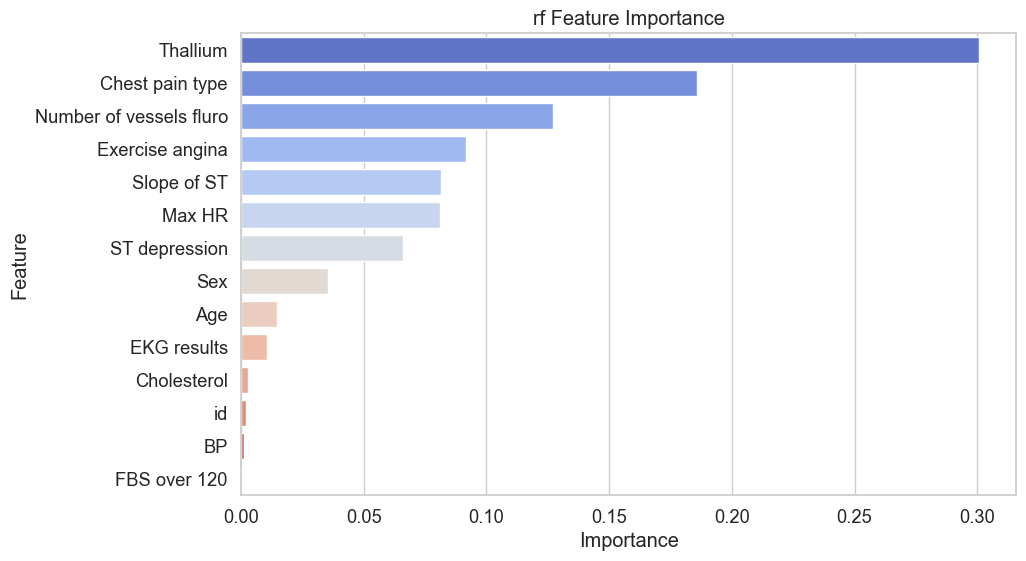

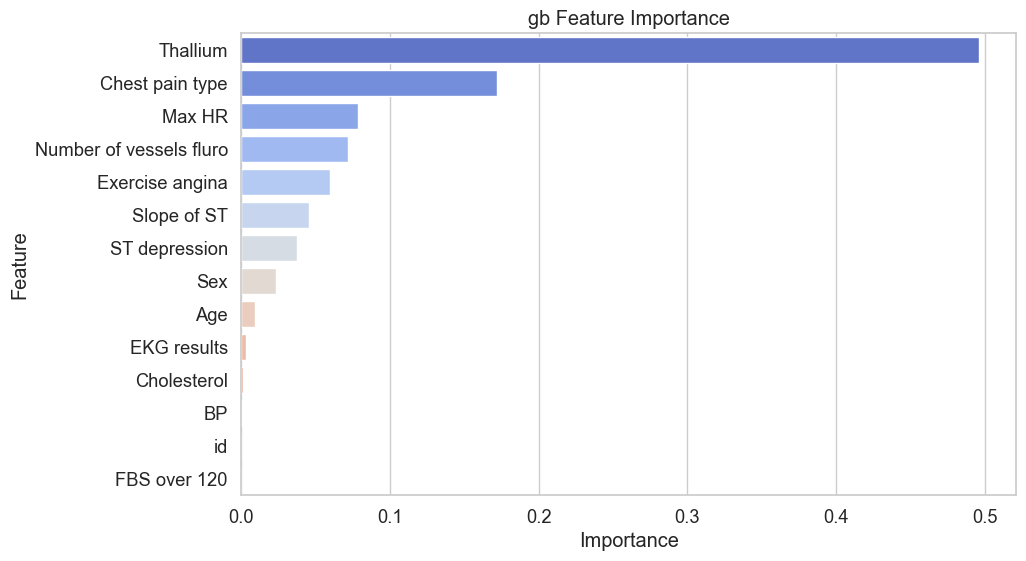

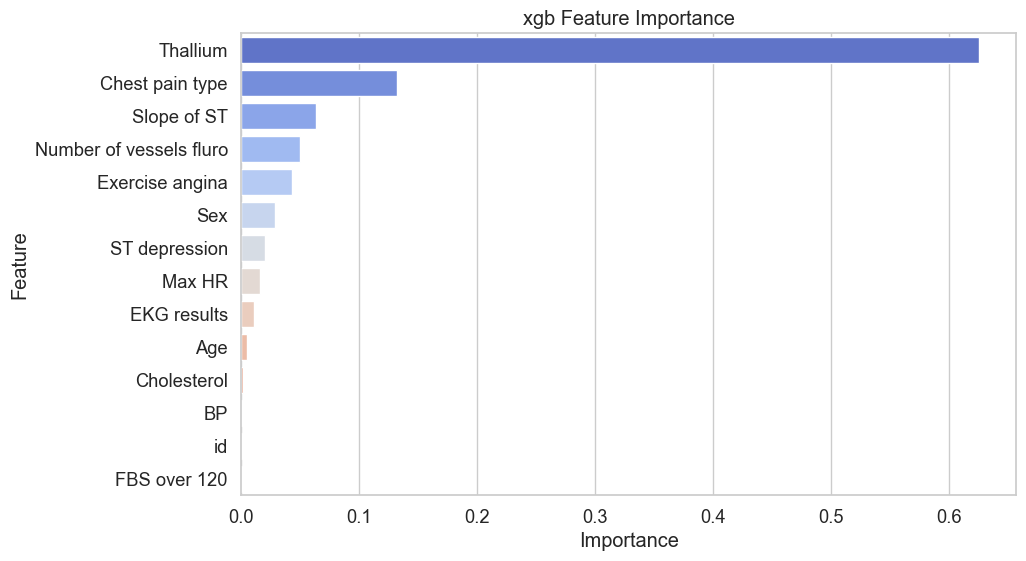

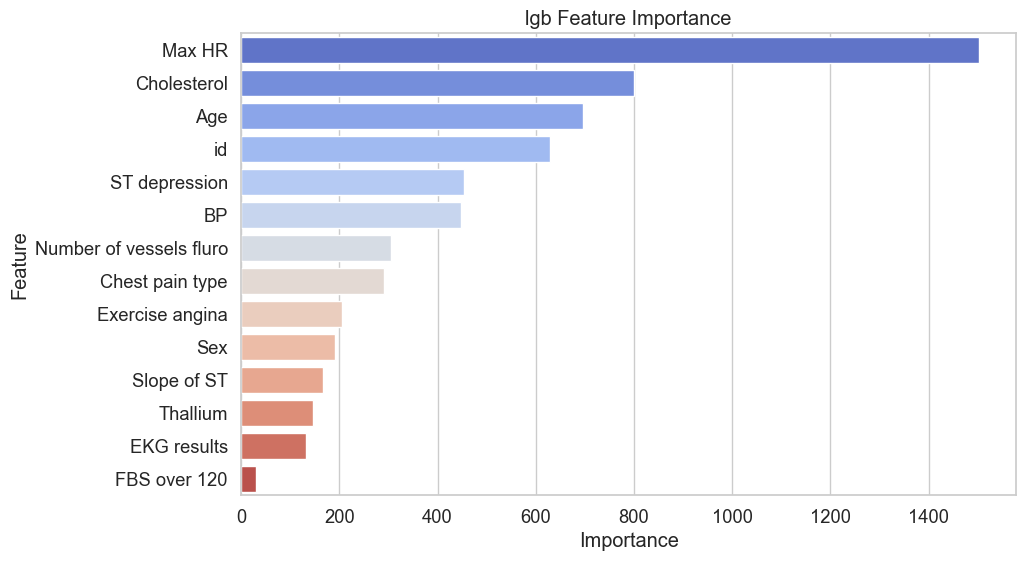

In [21]:
fitted_base_models = []
for name, model in stack_models:
    model.fit(X_train_scaled, y_train)
    fitted_base_models.append((name, model))

for name, model in fitted_base_models:
    if hasattr(model, 'feature_importances_'):
        feat_imp = pd.DataFrame({
            "Feature": X_train.columns,
            "Importance": model.feature_importances_
        }).sort_values("Importance", ascending=False)

        plt.figure(figsize=(10,6))
        sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="coolwarm")
        plt.title(f"{name} Feature Importance")
        plt.show()

4 - SHAP Analysis

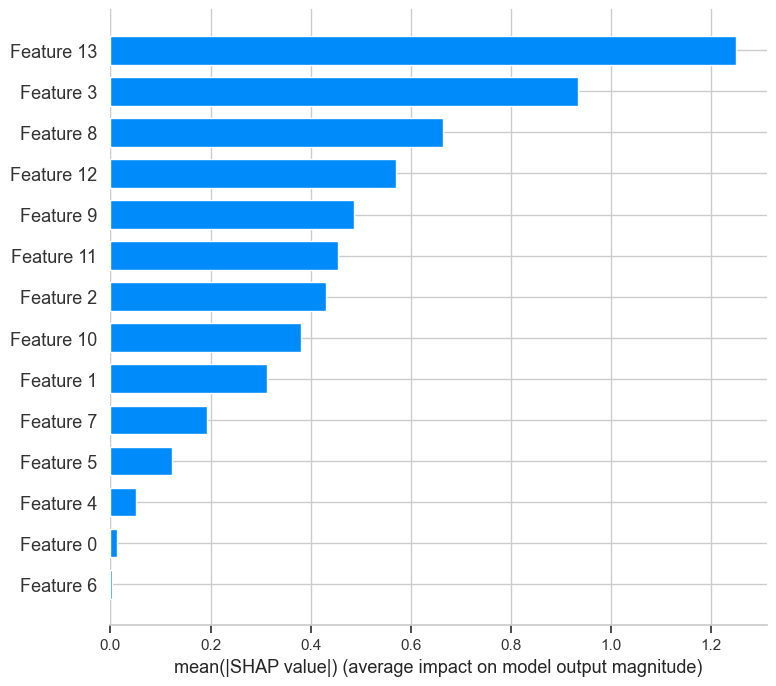

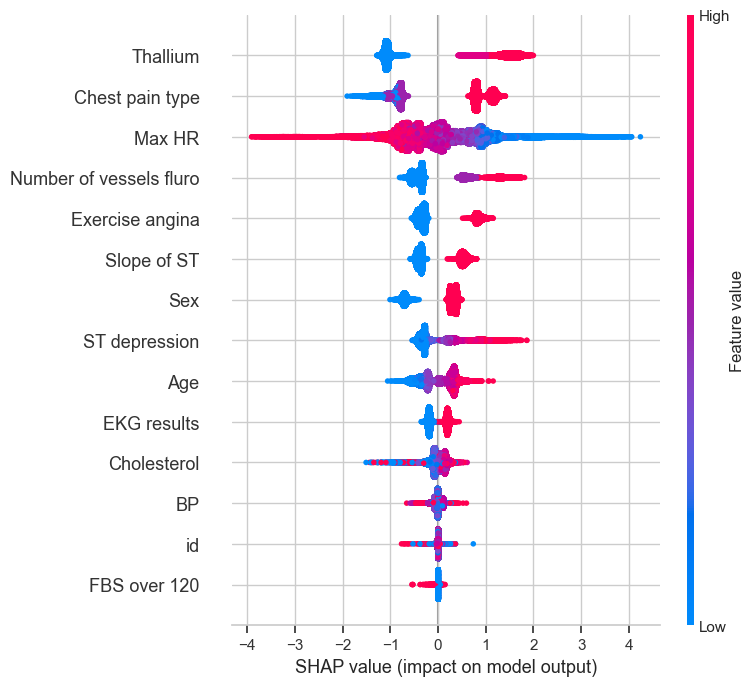

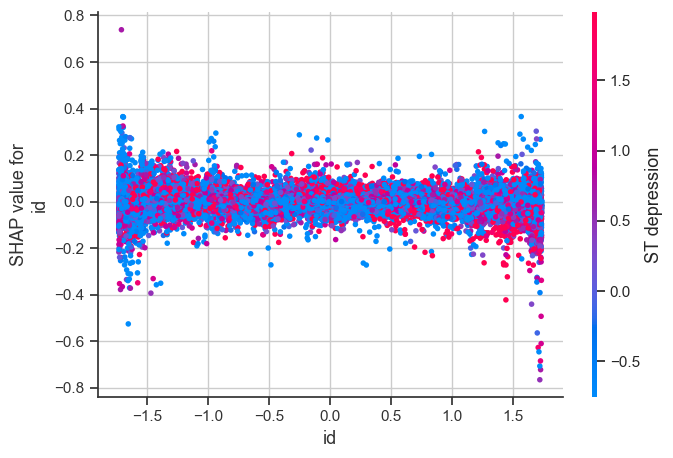

In [22]:
import shap

shap.initjs()
X_val_array = X_val_scaled

best_model = fitted_base_models[3][1]  

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val_array)

shap.summary_plot(shap_values, X_val_scaled, plot_type="bar")

shap.summary_plot(shap_values, X_val_array, feature_names=X_train.columns)

try:
    shap.force_plot(
        explainer.expected_value, 
        shap_values[0,:], 
        X_val_array[0,:],
        feature_names=X_train.columns
    )
except:
    print("Interactive force plot may not render in JupyterLab. Use the bar/dot summary plots instead .")

top_feature = X_train.columns[0]
shap.dependence_plot(top_feature, shap_values, X_val_array, feature_names=X_train.columns)


#### Threshold Optimization / Probability Calibration

In [23]:
from sklearn.metrics import precision_recall_curve, f1_score


probs = stack_clf.predict_proba(X_val_scaled)[:,1]

precision, recall, thresholds = precision_recall_curve(y_val, probs)

f1_scores = 2 * (precision * recall) / (precision + recall)

best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print("Optimal threshold for F1-score:", best_threshold)

y_val_pred_opt = (probs >= best_threshold).astype(int)


print("ROC-AUC:", roc_auc_score(y_val, probs))
print("Log Loss:", log_loss(y_val, probs))

Optimal threshold for F1-score: 0.39215945518430206
ROC-AUC: 0.9551284014486205
Log Loss: 0.27856765725302807


### Hyperparameter table:

In [24]:

tuning_summary = pd.DataFrame({
    "Model": [name for name, model in models.items()],
    "Used Parameters": [model.get_params() for name, model in models.items()]
})

tuning_summary

,Model,Used Parameters
0,Logistic Regression,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,Random Forest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w..."
2,Gradient Boosting,"{'ccp_alpha': 0.0, 'criterion': 'friedman_mse'..."
3,XGBoost,"{'objective': 'binary:logistic', 'base_score':..."
4,LightGBM,"{'boosting_type': 'gbdt', 'class_weight': None..."


### Hyperparameter Summary
The table below shows the parameters used for each base model in the ensemble.
These parameters were selected based on prior experiments to maximize validation performance.

### Final Predictions & Submission 

In [25]:
test_scaled = scaler.transform(test[X_train.columns])

test_preds = stack_clf.predict_proba(test_scaled)[:,1]

# Submission DataFrame

submission = pd.DataFrame({
    "id": test["id"],
    "Heart Disease": test_preds
})

submission.to_csv("submission.csv", index=False)
print("Submission file created! Here are the first 10 rows:")
display(submission.head(10))

Submission file created! Here are the first 10 rows:


,id,Heart Disease
0,630000,0.911184
1,630001,0.038271
2,630002,0.958582
3,630003,0.035850
4,630004,0.188239
5,630005,0.960239
6,630006,0.038349
7,630007,0.719205
8,630008,0.963278
9,630009,0.037804
